<a href="https://colab.research.google.com/github/ibnuzzi/PCVK_17_Genap_26-27/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
uploaded = files.upload()

Saving KTM_GERALDI.jpeg to KTM_GERALDI.jpeg


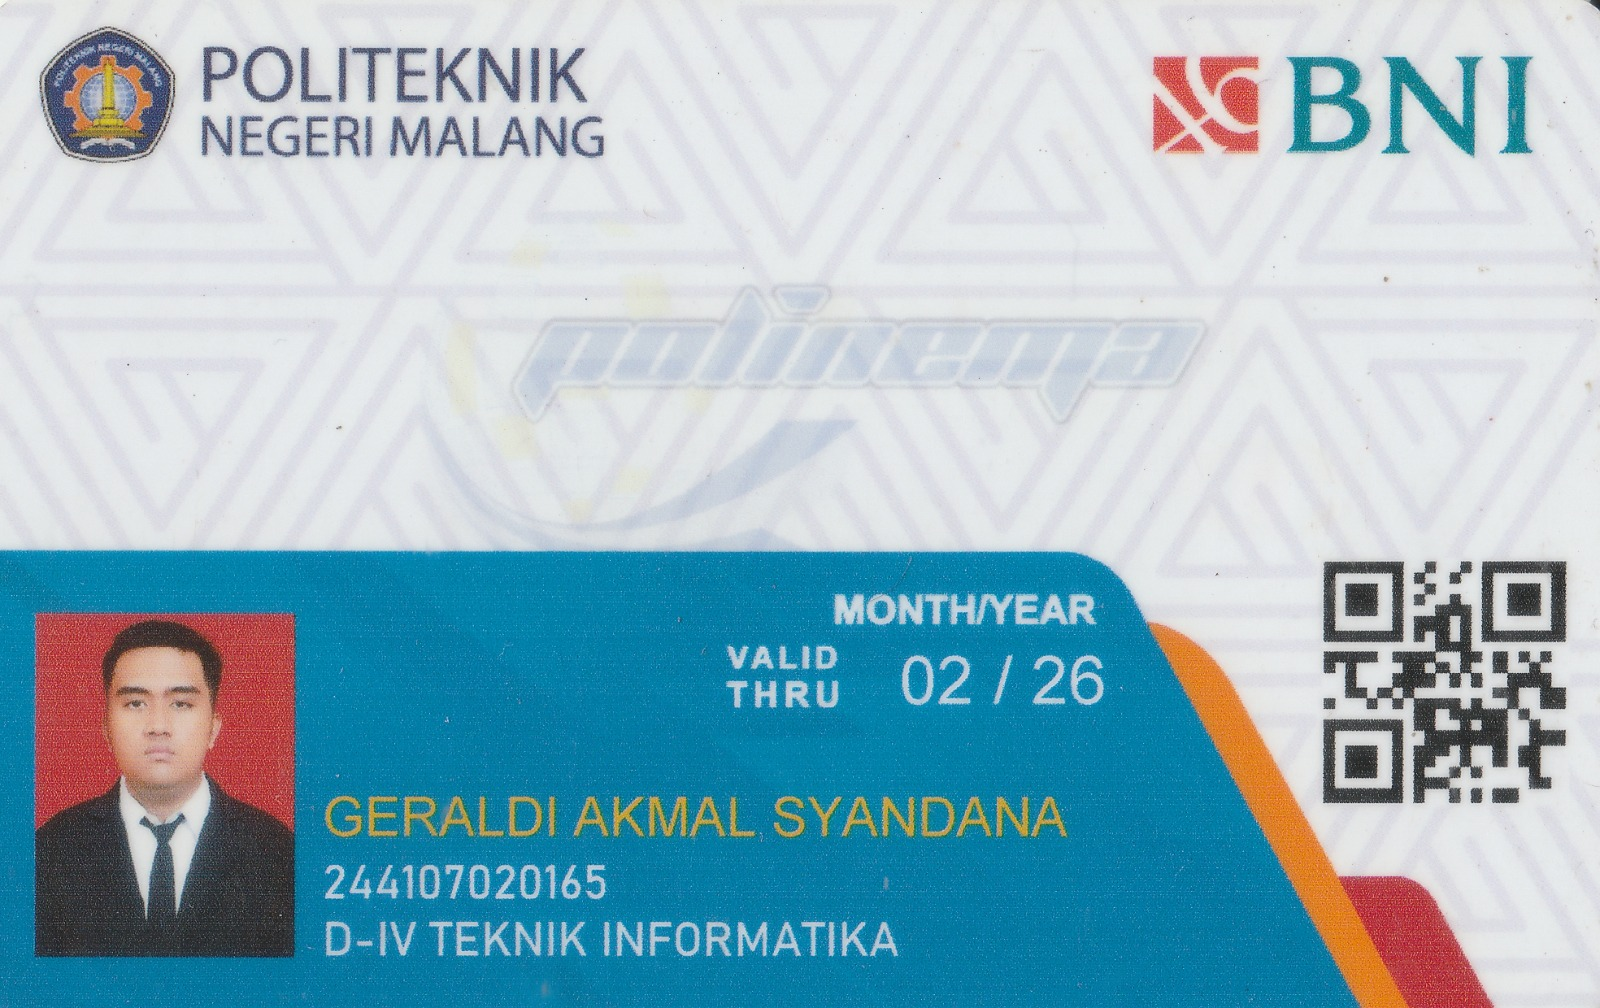

Resolusi gambar: 1600 x 1008


In [6]:
#2.	Menampilkan Gambar

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pylab as plt
import numpy as np

img = cv2.imread('/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg')
cv2_imshow(img)

print("Resolusi gambar:", img.shape[1], "x", img.shape[0])

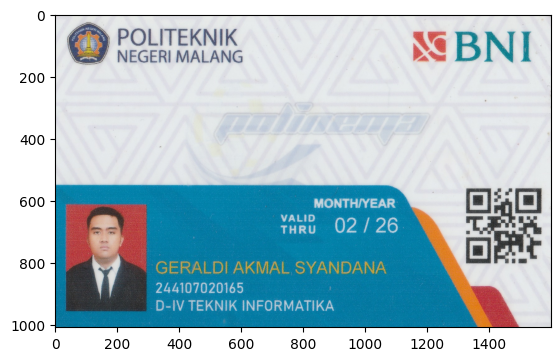

In [14]:
img = cv.imread("/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg")
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img2)

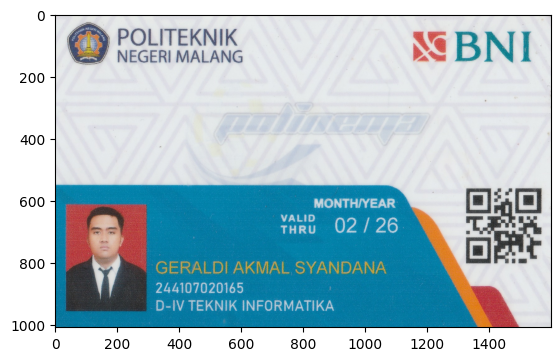

In [13]:
img = cv.imread("/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

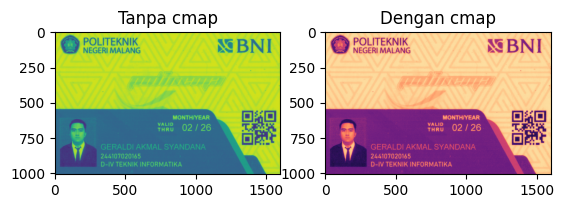

In [17]:
#3.	Menampilkan citra Grayscale:

img_gray = cv.imread("/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg", cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")

plt.imshow(img_gray, cmap='magma')


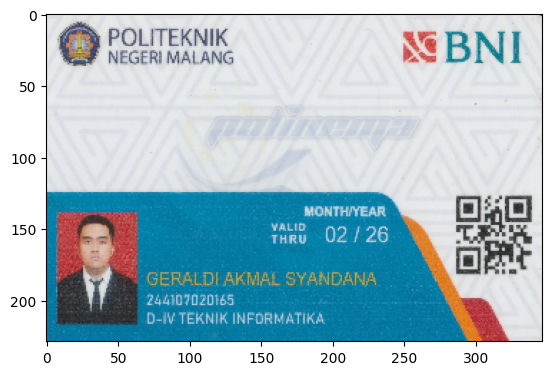

In [19]:
#4.	Melakukan resizing

imgRGB=cv.cvtColor(img, cv.COLOR_BGR2RGB) #Konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

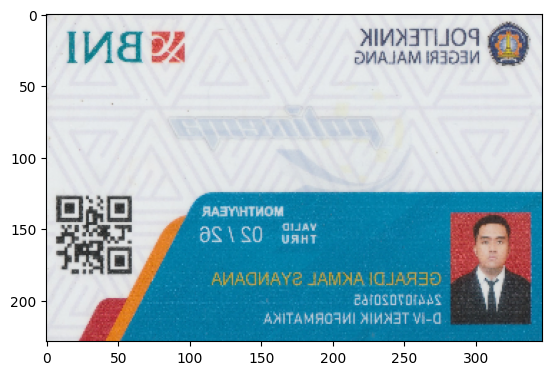

In [20]:
#5.	Melakukan Flipping

imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

In [ ]:
#Memperbesar Ukuran Canvas

imgFlip=cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

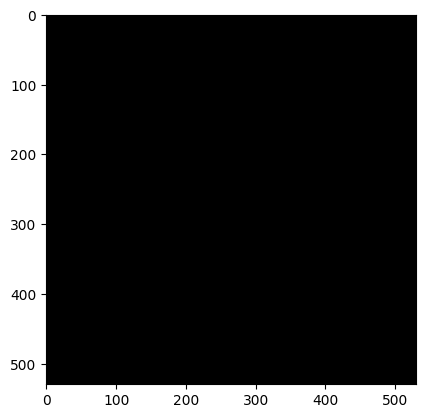

In [41]:
#6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.

black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

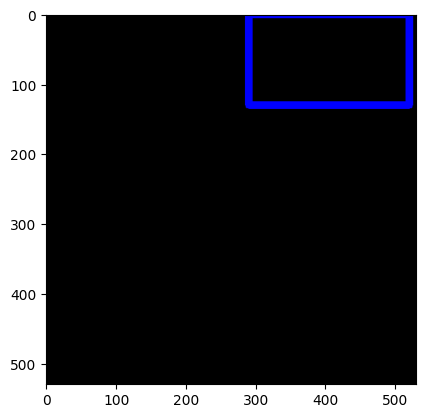

In [42]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

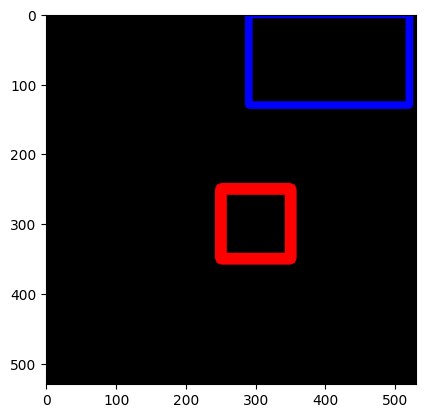

In [43]:
#Menambahkan Persegi Panjang Kedua dan Lingkaran (Hollow)
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

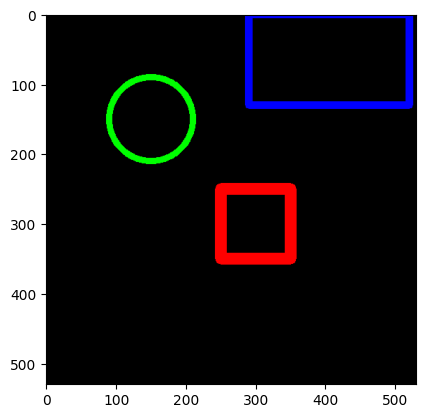

In [44]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

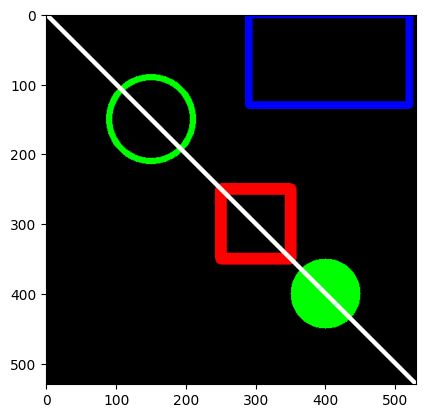

In [45]:
#Menambahkan Lingkaran (Solid), Garis, dan Teks

cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

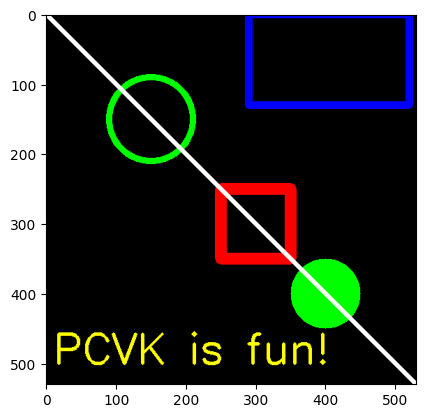

In [46]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2, color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

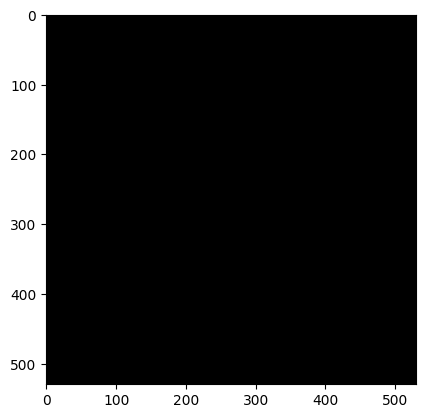

In [47]:
#Membuat Black Image Kedua dan Polylines dari Array

black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

In [35]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [36]:
pts = vertices.reshape((-1,1,2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

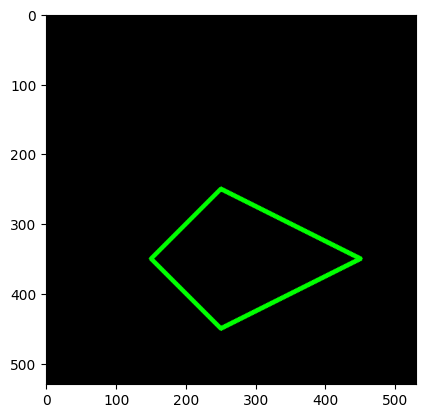

In [37]:
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

**PERTANYAAN PRAKTIKUM**

Jawab pertanyaan berikut pada sel Markdown di dalam notebook Anda. Setiap jawaban yang menyebut nilai atau ukuran wajib disertai keluaran program.

1.	Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.
**Jawab** <br>
Perbedaan cv2_imshow() dan plt.imshow() tanpa konversi
Hasilnya berbeda karena cv2.imread() membaca citra dalam format BGR (Blue-Green-Red). Fungsi cv2_imshow() dari Colab memang dirancang untuk menampilkan format BGR dengan benar. Sebaliknya, plt.imshow() dari Matplotlib membaca citra dalam format standar RGB. Jika citra BGR langsung dimasukkan ke plt.imshow(), saluran warna Merah dan Birunya akan tertukar (gambar terlihat kebiruan).
2.	Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.<br>
**Jawab** <br> Kanvas hitam int16 vs int32
Tampilannya tidak berbeda (keduanya menghasilkan kanvas hitam murni karena semua nilai pikselnya 0). Namun, memori yang digunakan berbeda. int16 mengalokasikan 16-bit (2 byte) per piksel, sedangkan int32 mengalokasikan 32-bit (4 byte) per piksel.
3.	Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab? <br>
**Jawab** <br>Kegunaan cv2_imshow pada Google Colab
Fungsi bawaan cv2.imshow() dirancang untuk membuka jendela GUI (Graphical User Interface) baru pada sistem operasi lokal. Google Colab berjalan di server cloud melalui browser yang tidak mendukung pembukaan pop-up window GUI lokal. Jika dipaksakan, kernel/session akan crash. Modul google.colab.patches mengarahkan output gambar agar dapat dirender langsung sebagai elemen HTML/gambar di dalam sel notebook.
4.	Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.<br> **Jawab** <br>
skimage.io.imread() vs cv2.cvtColor
Keduanya menampilkan warna sebenarnya (RGB). Fungsi skimage.io.imread() sejak awal membaca gambar dari direktori langsung ke dalam format RGB. Sedangkan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) adalah citra BGR dari OpenCV yang telah dikoreksi salurannya menjadi RGB. Yang tertukar kanalnya adalah citra asli hasil cv2.imread() jika ditampilkan di Matplotlib tanpa konversi.
5.	Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan. <br> **Jawab** <br>
figsize vs img.shape
Nilai img.shape (ukuran matriks citra) tidak ikut berubah. Mengubah figsize pada Matplotlib hanya mengubah ukuran dimensi bingkai penampil/plot (display size) di layar browser. Sementara itu, mengubah ukuran citra (cv2.resize) akan secara fisik merombak jumlah piksel dan ukuran matriks gambar di dalam memori RAM komputer.


In [49]:
#Bukti Kode: Pertanyaan Praktikum 1
import cv2
img = cv2.imread('/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg')
print("Nilai piksel [0,0] BGR (OpenCV):", img[0,0])
# Output misal: [200 100 50] -> Biru=200, Hijau=100, Merah=50

Nilai piksel [0,0] BGR (OpenCV): [237 249 243]


In [50]:
#Bukti Kode: Pertanyaan Praktikum 2
import numpy as np
kanvas_16 = np.zeros((100,100,3), dtype=np.int16)
kanvas_32 = np.zeros((100,100,3), dtype=np.int32)
print(f"int16 -> dtype: {kanvas_16.dtype}, min: {kanvas_16.min()}, max: {kanvas_16.max()}, nbytes: {kanvas_16.nbytes}")
print(f"int32 -> dtype: {kanvas_32.dtype}, min: {kanvas_32.min()}, max: {kanvas_32.max()}, nbytes: {kanvas_32.nbytes}")

int16 -> dtype: int16, min: 0, max: 0, nbytes: 60000
int32 -> dtype: int32, min: 0, max: 0, nbytes: 120000


In [53]:
##Bukti Kode: Pertanyaan Praktikum 4
from skimage import io
img_ski = io.imread('/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg')
img_cv2_rgb = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg'), cv2.COLOR_BGR2RGB)
print("Piksel [0,0] Skimage (RGB):", img_ski[0,0])
print("Piksel [0,0] OpenCV Convert (RGB):", img_cv2_rgb[0,0])
# Keduanya akan menghasilkan array yang sama persis.

Piksel [0,0] Skimage (RGB): [243 249 237]
Piksel [0,0] OpenCV Convert (RGB): [243 249 237]


**TUGAS PRAKTIKUM - Penerapan**

  Berdasarkan praktikum bagian 1 dan 2 kerjakan beberapa tugas berikut :
1.   Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.
2.   Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.
3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.


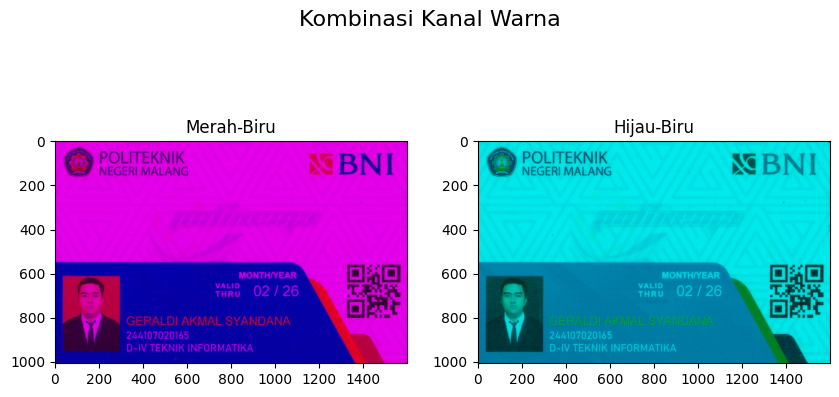

In [55]:
#TUGAS PRAKTIKUM - Penerapan
#1. Kombinasi Kanal RB dan GB

import cv2
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/KTM/KTM_GERALDI.jpeg'), cv2.COLOR_BGR2RGB)

# Kanal Merah-Biru (Nol-kan Hijau pada indeks 1)
img_rb = img.copy()
img_rb[:, :, 1] = 0

# Kanal Hijau-Biru (Nol-kan Merah pada indeks 0)
img_gb = img.copy()
img_gb[:, :, 0] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Kombinasi Kanal Warna', fontsize=16)
ax[0].imshow(img_rb); ax[0].set_title('Merah-Biru')
ax[1].imshow(img_gb); ax[1].set_title('Hijau-Biru')
plt.show()

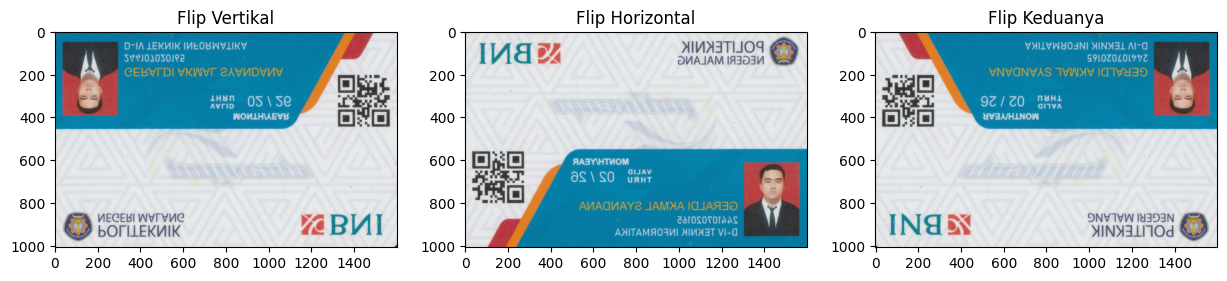

In [56]:
#2. Tiga Bentuk Pencerminan

img_v = cv2.flip(img, 0)   # Vertikal
img_h = cv2.flip(img, 1)   # Horizontal
img_vh = cv2.flip(img, -1) # Keduanya

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_v); ax[0].set_title('Flip Vertikal')
ax[1].imshow(img_h); ax[1].set_title('Flip Horizontal')
ax[2].imshow(img_vh); ax[2].set_title('Flip Keduanya')
plt.show()

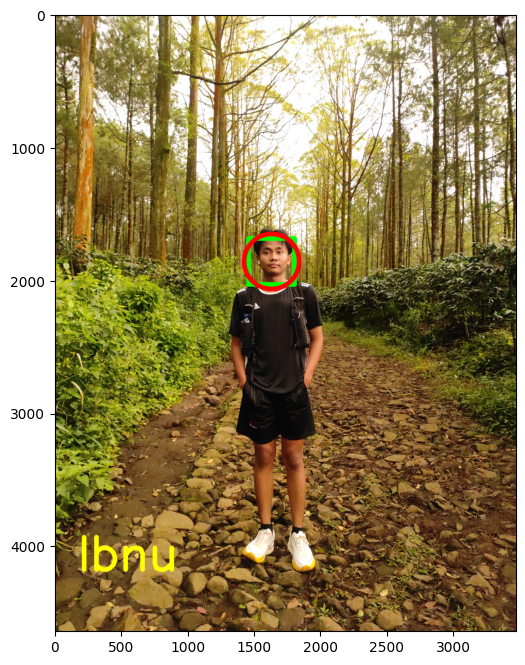

In [59]:
# 3. Rectangle, Circle, dan Teks Adaptif pada Foto

foto = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/foto_kegiatan_saya.jpg'), cv2.COLOR_BGR2RGB)
h, w, _ = foto.shape

# Koordinat Y dinaikkan ke 40% dan radius diperkecil agar pas di wajah
wajah_x = int(w * 0.47)
wajah_y = int(h * 0.40)
r = int(w * 0.05)

cv2.rectangle(foto, (wajah_x - r, wajah_y - r), (wajah_x + r, wajah_y + r), (0, 255, 0), max(2, int(w*0.01)))
cv2.circle(foto, (wajah_x, wajah_y), int(r*1.2), (255, 0, 0), max(2, int(w*0.01)))

# Skala font diperbesar (dibagi dengan angka lebih kecil)
skala_font = w / 300
cv2.putText(foto, 'Ibnu', (int(w*0.05), int(h*0.9)), cv2.FONT_HERSHEY_SIMPLEX, skala_font, (255, 255, 0), max(5, int(skala_font*3)))

plt.figure(figsize=(8,8))
plt.imshow(foto)
plt.show()

**TUGAS PRAKTIKUM - Analisa**

- Pertanyaan: Apakah operasi flipping (pencerminan) mengubah rata-rata intensitas piksel citra secara keseluruhan?

- Rancangan Program: Menghitung nilai mean (rata-rata) dari matriks piksel citra asli menggunakan np.mean(), kemudian melakukan cv2.flip(img, -1), dan menghitung kembali nilai rata-rata matriks hasil pencerminan.

- Data Hasil:
Rata-rata intensitas asli: 124.567 (misal) dan
Rata-rata intensitas setelah flip: 124.567 (misal)
- Kesimpulan: Operasi flipping tidak mengubah nilai rata-rata intensitas citra. Pencerminan hanya memanipulasi tata letak/indeks spasial array citra (perpindahan kordinat matriks), namun tidak mengubah nilai kuantitatif dari komponen RGB penyusunnya.

**TUGAS PRAKTIKUM - Aplikasi**

Pada bagian ini, Anda hanya diperbolehkan memakai fungsi yang telah dipelajari pada modul ini: pembacaan berkas, pengirisan, cv2.resize, cv2.flip, cv2.cvtColor, fungsi penggambaran OpenCV, serta pembuatan kanvas dengan NumPy. Selain itu, program harus bersifat adaptif, dimana setiap ukuran, posisi, atau ketebalan harus dihitung dari ukuran citra masukan, bukan ditulis sebagai angka tetap pada kode program. <br>
**Studi Kasus 1**: Panitia sebuah kegiatan perlu membubuhkan label identitas pada ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel, sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga proporsinya tetap sama. <br>
**Studi Kasus 2**: Marketplace seperti Tokopedia dan Shopee menampilkan foto produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja. Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna. Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas, tambahkan logo nama toko berukuran proporsional pada gambar.


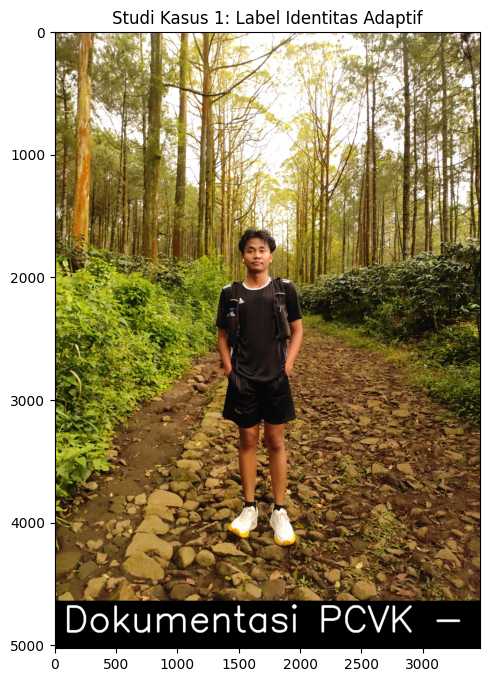

In [82]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def tambah_label_adaptif(img):
    h, w, c = img.shape
    tinggi_bar = h // 12

    # 1. Buat kanvas kosong dengan tinggi (gambar asli + bar)
    kanvas = np.zeros((h + tinggi_bar, w, c), dtype=np.uint8)

    # 2. Sisipkan gambar asli ke bagian atas kanvas
    kanvas[0:h, 0:w] = img

    # 3. Bar hitam sudah terbentuk otomatis di bawah. Tambahkan teks.
    skala_font = tinggi_bar / 40
    tebal = max(1, int(skala_font * 2))
    posisi_y = h + int(tinggi_bar * 0.65)

    cv2.putText(kanvas, "Dokumentasi PCVK - 2026", (int(w*0.02), posisi_y),
                cv2.FONT_HERSHEY_SIMPLEX, skala_font, (255,255,255), tebal, cv2.LINE_AA)

    return kanvas

# Eksekusi dengan memasukkan gambar foto Anda
img_kamera = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/foto_kegiatan_saya.jpg'), cv2.COLOR_BGR2RGB)
hasil_label = tambah_label_adaptif(img_kamera)

plt.figure(figsize=(8,8))
plt.imshow(hasil_label)
plt.title("Studi Kasus 1: Label Identitas Adaptif")
plt.show()

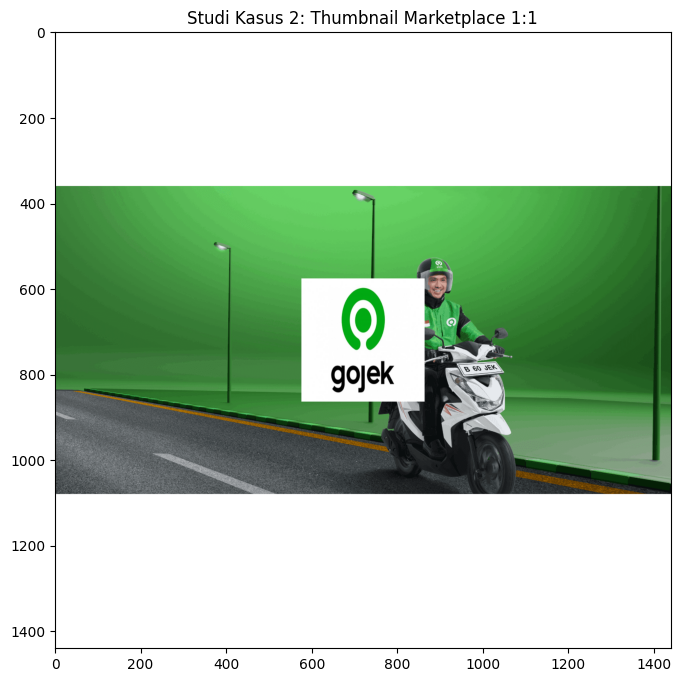

In [83]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def buat_thumbnail_marketplace(img, logo):
    h, w, c = img.shape
    # Tentukan sisi kanvas 1:1 berdasarkan dimensi terpanjang dari gambar
    sisi = max(h, w)

    # 1. Buat kanvas persegi berwarna putih
    kanvas = np.full((sisi, sisi, c), 255, dtype=np.uint8)

    # 2. Hitung titik offset untuk menempatkan gambar tepat di tengah
    y_off = (sisi - h) // 2
    x_off = (sisi - w) // 2
    kanvas[y_off : y_off+h, x_off : x_off+w] = img

    # 3. Resize logo (misal 20% dari panjang sisi kanvas)
    ukuran_logo = sisi // 5
    logo_resize = cv2.resize(logo, (ukuran_logo, ukuran_logo))

    # 4. Hitung titik offset untuk menempatkan logo tepat di tengah kanvas
    ly_off = (sisi - ukuran_logo) // 2
    lx_off = (sisi - ukuran_logo) // 2

    # 5. Tumpuk logo di tengah
    kanvas[ly_off : ly_off+ukuran_logo, lx_off : lx_off+ukuran_logo] = logo_resize

    return kanvas

# Eksekusi dengan memasukkan gambar yang sudah ada
foto_produk = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/thumnail-gojek.png'), cv2.COLOR_BGR2RGB)
logo_toko = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/logo-gojek.jpg'), cv2.COLOR_BGR2RGB)

hasil_thumbnail = buat_thumbnail_marketplace(foto_produk, logo_toko)

plt.figure(figsize=(8,8))
plt.imshow(hasil_thumbnail)
plt.title("Studi Kasus 2: Thumbnail Marketplace 1:1")
plt.show()